In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

import os
os.chdir("..")

from src.data import load_data
from src.shap import get_full_masks, explain_sample


DEVICE = "cuda"

## Load the trained model

In [2]:
model = torch.load("exogenous_transformer.pt", weights_only=False)
model.eval()

ExogenousTransformer(
  (encoder_embedding): FeatureEmbedding(
    (embeddings): ParameterDict(
        (load): Object of type: LinearEmbedding
        (hourofday): Object of type: CategoricalEmbedding
        (dayofweek): Object of type: CategoricalEmbedding
        (month): Object of type: CategoricalEmbedding
        (holiday): Object of type: CategoricalEmbedding
        (temperature): Object of type: LinearEmbedding
        (precipitation): Object of type: LinearEmbedding
      (load): LinearEmbedding(
        (embedding): Linear(in_features=1, out_features=32, bias=True)
      )
      (hourofday): CategoricalEmbedding(
        (embedding): Embedding(24, 32)
      )
      (dayofweek): CategoricalEmbedding(
        (embedding): Embedding(7, 32)
      )
      (month): CategoricalEmbedding(
        (embedding): Embedding(12, 32)
      )
      (holiday): CategoricalEmbedding(
        (embedding): Embedding(2, 32)
      )
      (temperature): LinearEmbedding(
        (embedding): Linea

## Load the test data

In [3]:
data = load_data("data/transnet/test.json", device=DEVICE)

## Select the first sample

In [4]:
sample = data[0]
x_enc = sample["x_enc"]
x_dec = sample["x_dec"]
y = sample["y"]

## Visualize the sample

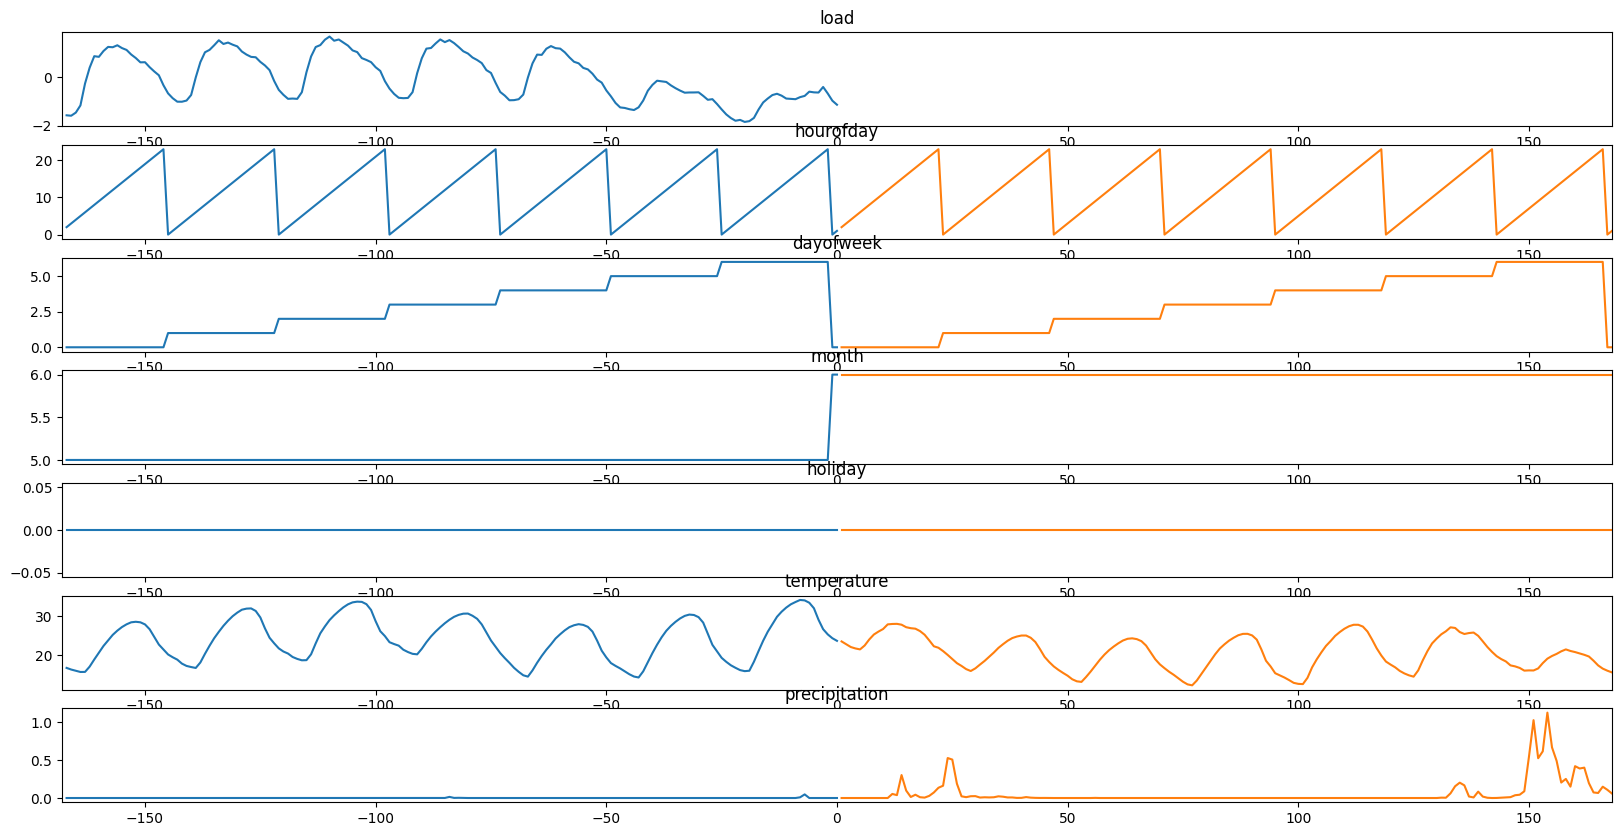

In [5]:
fig, axs = plt.subplots(len(x_enc), 1, figsize=(20, 10))
past_hours = np.arange(-167, 1)
future_hours = np.arange(1, 169)
for i, feature in enumerate(x_enc):
    axs[i].plot(past_hours, x_enc[feature].cpu().numpy())
    if feature in x_dec:
        axs[i].plot(future_hours, x_dec[feature].cpu().numpy())
    axs[i].set_xlim(-168, 168)
    axs[i].set_title(feature)

## Generate an explanation with SHAPformer

In [6]:
x_enc = {k: v.unsqueeze(0) for k, v in x_enc.items()}
x_dec = {k: v.unsqueeze(0) for k, v in x_dec.items()}

ft_mask, attn_mask = get_full_masks(len(x_enc), device=DEVICE)

with torch.no_grad():
    output = model(x_enc, x_dec, mask_enc=ft_mask[None, :], mask_dec=ft_mask[None, 1:], attn_mask=attn_mask[None, :, :])

explanation = explain_sample(model, sample)
print(explanation.keys())

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 64/64 [00:00<00:00, 110.66it/s]


dict_keys(['prediction', 'base', 'shap_values'])


## Plot the prediction and ground truth

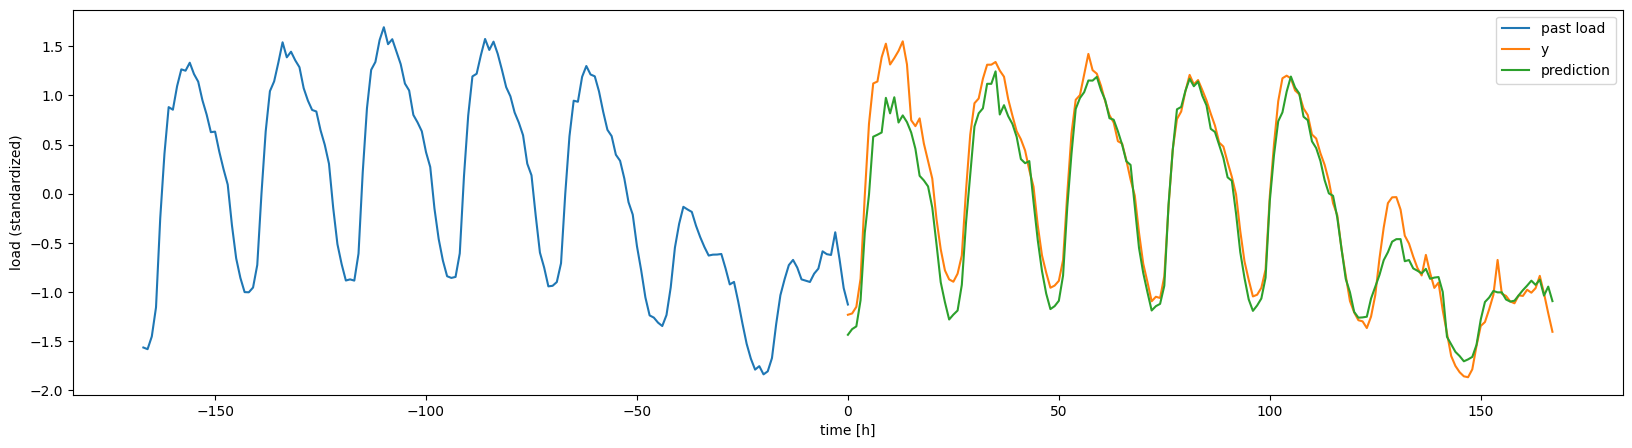

In [7]:
plt.figure(figsize=(20, 5))
plt.plot(np.arange(-167, 1), x_enc["load"][0, :].cpu().numpy(), label="past load")
plt.plot(y.cpu().numpy(), label="y")
plt.plot(explanation["prediction"], label="prediction")
plt.xlabel("time [h]")
plt.ylabel("load (standardized)")
plt.legend()
plt.show()

## Visualize the explanation

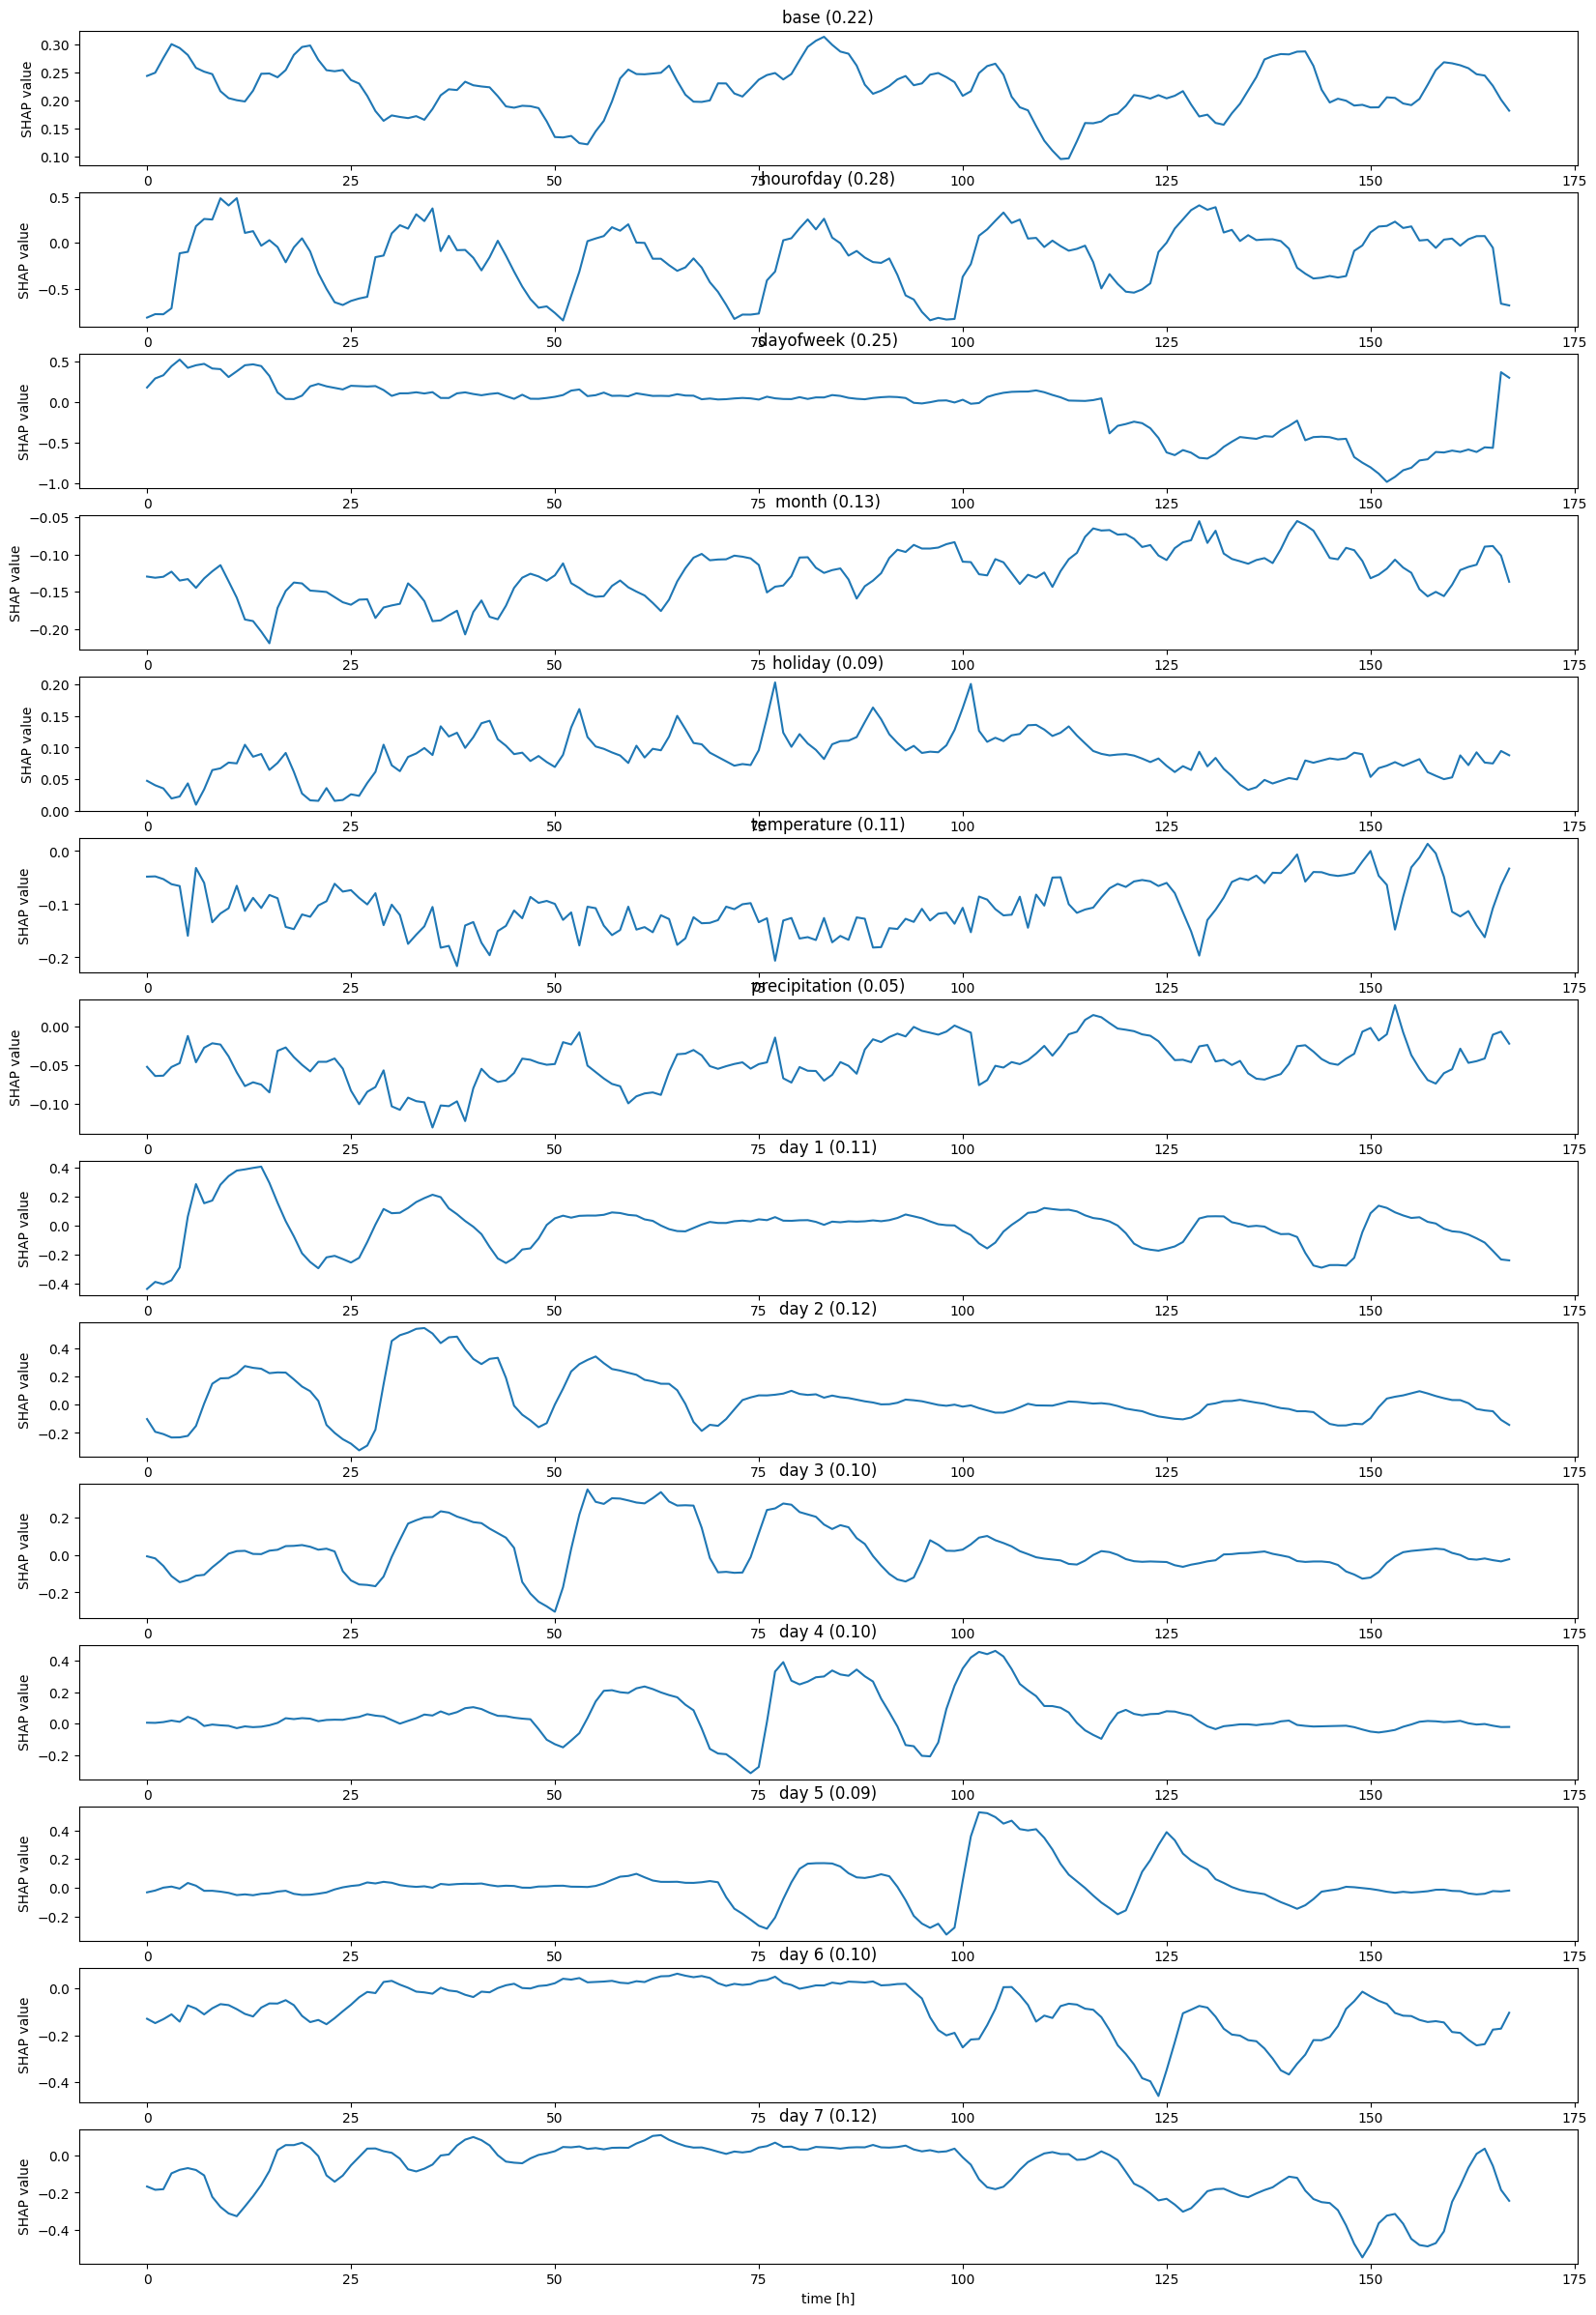

In [8]:
shap_values = explanation["shap_values"]

fig, axs = plt.subplots(len(shap_values) + 1, 1, figsize=(20, 30))

base_importance = np.mean(np.abs(explanation["base"]))
axs[0].plot(explanation["base"])
axs[0].set_title(f"base ({base_importance:.2f})")

for i, feature in enumerate(shap_values):
    ft_shap_vals = shap_values[feature]
    importance = np.mean(np.abs(ft_shap_vals))
    axs[i + 1].plot(ft_shap_vals)
    axs[i + 1].set_title(f"{feature} ({importance:.2f})")

for i in range(len(shap_values) + 1):
    axs[i].set_xlabel("time [h]")
    axs[i].set_ylabel("SHAP value")

plt.show()